# AVD on a high-dimensional Roessler signal

This notebook builds a **high-dimensional multivariate signal** by mixing a 3-D Roessler attractor into many channels using [simulation_data.py](simulation_data.py), then runs the AVD dimension-reduction on the result and plots the curves.

The Roessler attractor is a chaotic 3-D ODE; mixing it into `D > 3` channels with a random linear matrix gives a multivariate signal whose channels share the same underlying dynamics but with different per-channel weights — a clean test case for AVD, which measures *disagreement* in per-channel volatility.

## Imports

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint

from simulation_data import simulation_data
from AVD_function import calculate_AVD_feature

## 1. The underlying 3-D Roessler attractor

Just for context, integrate the Roessler ODE directly with the same parameters and initial values that `simulation_data.py` uses internally (`a=0.15, b=0.20, c=10`, `yinit=[5, 1, 1]`).

underlying Roessler shape (3 dims, T): (3, 10001)


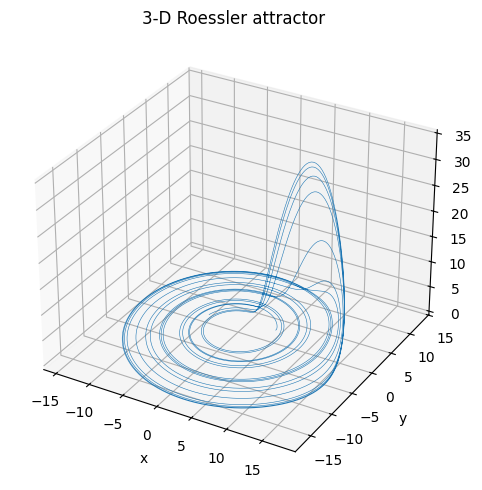

In [60]:
a, b, c = 0.15, 0.20, 10
f_roessler = lambda x, t: [-x[1] - x[2], x[0] + a * x[1], b + x[2] * (x[0] - c)]

interv_length = 100
sample_rate = 100
t_grid = np.arange(0, interv_length + 1 / sample_rate, 1 / sample_rate)
yinit = [5, 1, 1]

x_data = odeint(f_roessler, yinit, t_grid, rtol=1e-4, atol=1e-4, h0=0.5, hmax=0.5).T
print('underlying Roessler shape (3 dims, T):', x_data.shape)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_data[0], x_data[1], x_data[2], lw=0.4)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('3-D Roessler attractor')
plt.tight_layout()
plt.show()

## 2. Generate a high-dimensional signal via `simulation_data`

`simulation_data('Roessler', ...)` integrates the same 3-D Roessler internally and then mixes it into a `Dimension`-channel signal using an internal random matrix `MixMatrix_wi`. We add a small fixed additive noise (`FixAdditiveNoise=20` dB) so the result is deterministic across runs.

In [61]:
#   N=20 channels, n=3 Roessler dims, p=17 component-noise dims,
#   FixComponentNoise=0, FixAdditiveNoise=100, SampleRate=100,
#   then downsample with step = L*dt (dt=0.5 -> every 50th sample).
N_DIM = 20              # signal dimension N
N_SIG = 3               # n - intrinsic Roessler dimensions
N_NOISE = 17            # p - component-noise dimensions
INTERV_LENGTH = 100
SAMPLE_RATE = 100
FIX_COMPONENT_NOISE = 0
FIX_ADDITIVE_NOISE = 20

# One mix matrix split into W (signal) and Psi (component noise), like MATLAB
rng = np.random.default_rng(0)
MixMatrix = rng.random((N_DIM, N_SIG + N_NOISE))   # (N, n+p)
W = MixMatrix[:, :N_SIG]                           # (N, n)
Psi = MixMatrix[:, N_SIG:]                         # (N, p)

# simulation_data expects (n, N) and (p, N) -> transpose vs MATLAB
dic = simulation_data(
    'Roessler',
    IntervLength=INTERV_LENGTH,
    SampleRate=SAMPLE_RATE,
    MixMatrix_wi=W.T,
    MixMatrix_psij=Psi.T,
    FixComponentNoise=FIX_COMPONENT_NOISE,
    FixAdditiveNoise=FIX_ADDITIVE_NOISE,
)

time_vec = dic['TimeSignal']
high_d = dic['SampleSignal']      # shape: (N_DIM, T)

print('high-D signal shape (channels, T):', high_d.shape)
print('time vector shape:', time_vec.shape)

AmplitudeNoise is not activated
ComponentNoise is not activated
AdditiveNoise is not activated
AmplitudeNoise is not activated
ComponentNoise is activated
AdditiveNoise is activated
high-D signal shape (channels, T): (20, 10001)
time vector shape: (10001,)


## 3. Inspect a few channels

The mixed channels are linear combinations of `x, y, z` from the Roessler attractor, so they all share the same chaotic dynamics but with different scales and shapes.

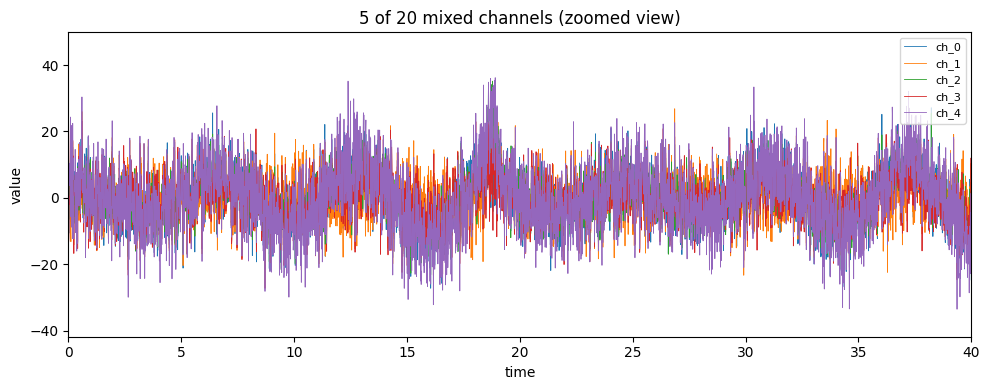

In [62]:
signal_df = pd.DataFrame(high_d.T, index=time_vec, columns=[f'ch_{i}' for i in range(N_DIM)])
signal_df.index.name = 'time'

fig, ax = plt.subplots(figsize=(10, 4))
for col in signal_df.columns[:5]:
    ax.plot(signal_df.index, signal_df[col], lw=0.6, label=col)
ax.set_xlabel('time')
ax.set_ylabel('value')
ax.set_title(f'5 of {N_DIM} mixed channels (zoomed view)')
ax.set_xlim(0, 40)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 4. Compute AVD on the high-dimensional signal

Mean-normalise per channel (so AVD picks up *fluctuations* rather than absolute level differences) and run `calculate_AVD_feature` for both `MAD` and `SD`. The window is roughly two Roessler quasi-periods wide.

In [63]:
W_SIZE = 200    # 200 samples = 2 time units at sample_rate=100
W_INCRE = 20

normalized = signal_df - signal_df.mean(axis=0)

avd_mad = calculate_AVD_feature(normalized, metric='MAD', w_size=W_SIZE, w_incre=W_INCRE)
avd_sd = calculate_AVD_feature(normalized, metric='SD', w_size=W_SIZE, w_incre=W_INCRE)

# map window-end indices back to actual time values
mad_time = time_vec[avd_mad.index.values]
sd_time = time_vec[avd_sd.index.values]

print(f'AVD windows: {len(avd_mad)} (MAD), {len(avd_sd)} (SD)')
avd_mad.head()

AVD windows: 491 (MAD), 491 (SD)


,MAD
Time Point,
199,0.731474
219,0.629264
239,0.628514
259,0.653676
279,0.738904


## 5. Plot AVD curves

The top panel overlays a few of the mixed channels (the input). The bottom two panels show the two AVD curves on the same time axis, so you can see which segments of the Roessler trajectory generate the largest cross-channel volatility disagreement.

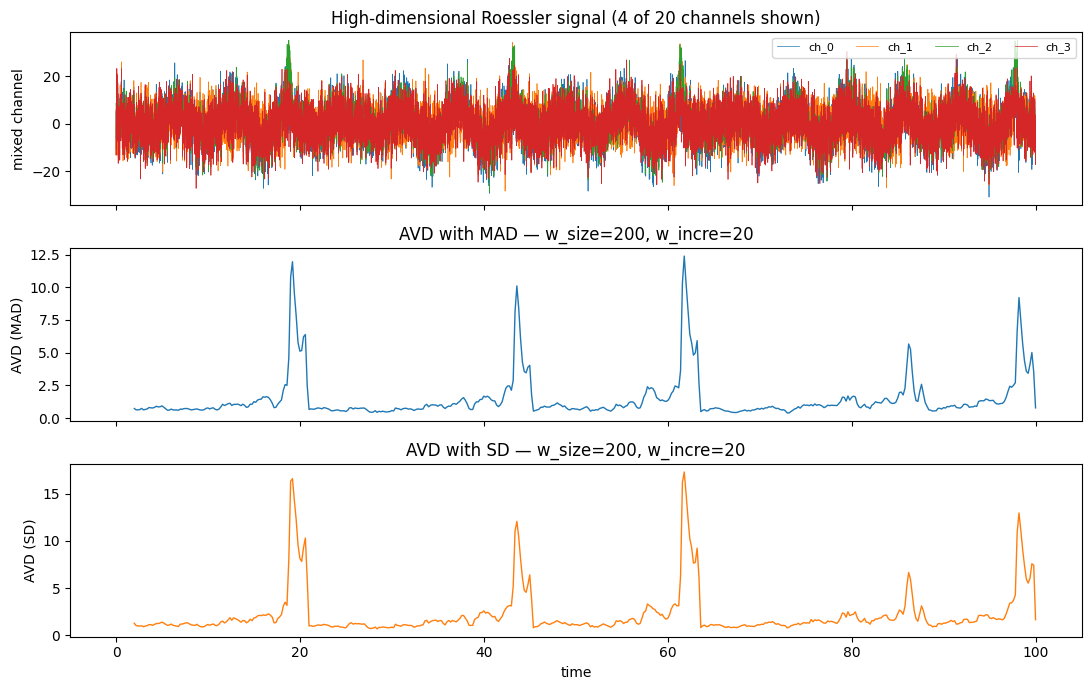

In [64]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

for col in signal_df.columns[:4]:
    axes[0].plot(signal_df.index, signal_df[col], lw=0.5, label=col)
axes[0].set_ylabel('mixed channel')
axes[0].set_title('High-dimensional Roessler signal (4 of {N} channels shown)'.format(N=N_DIM))
axes[0].legend(loc='upper right', fontsize=8, ncol=4)

axes[1].plot(mad_time, avd_mad['MAD'].values, color='C0', lw=1.0)
axes[1].set_ylabel('AVD (MAD)')
axes[1].set_title(f'AVD with MAD — w_size={W_SIZE}, w_incre={W_INCRE}')

axes[2].plot(sd_time, avd_sd['SD'].values, color='C1', lw=1.0)
axes[2].set_ylabel('AVD (SD)')
axes[2].set_xlabel('time')
axes[2].set_title(f'AVD with SD — w_size={W_SIZE}, w_incre={W_INCRE}')

plt.tight_layout()
plt.show()

## 6. MAD vs. SD on the same axes

Same data, two volatility measures. Shapes are similar; SD-based AVD is generally larger in magnitude because squared deviations grow faster than absolute ones.

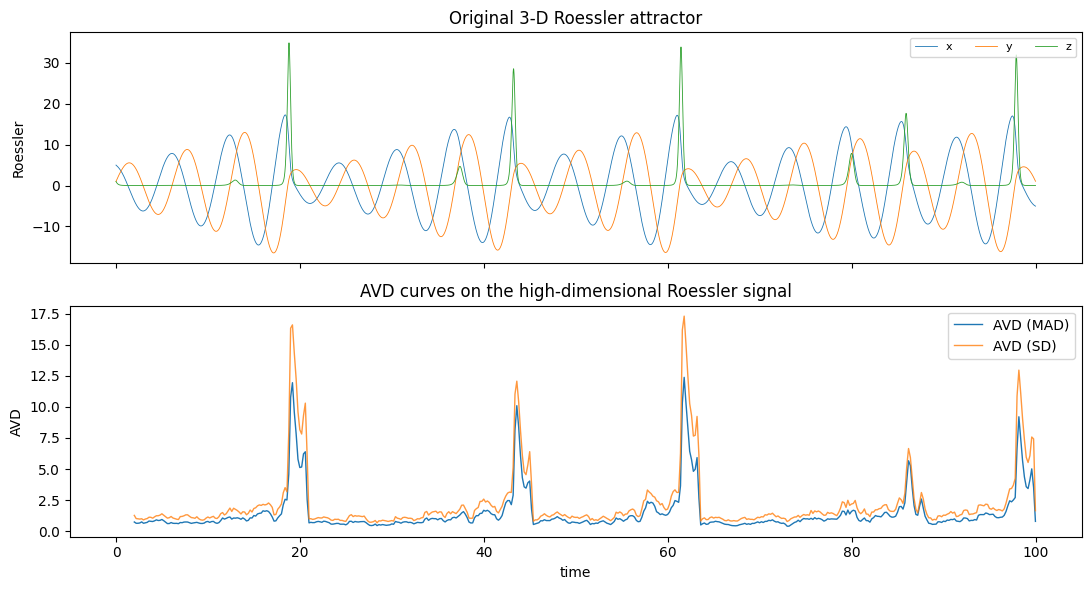

In [65]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(t_grid, x_data[0], lw=0.6, label='x')
axes[0].plot(t_grid, x_data[1], lw=0.6, label='y')
axes[0].plot(t_grid, x_data[2], lw=0.6, label='z')
axes[0].set_ylabel('Roessler')
axes[0].set_title('Original 3-D Roessler attractor')
axes[0].legend(loc='upper right', fontsize=8, ncol=3)

axes[1].plot(mad_time, avd_mad['MAD'].values, label='AVD (MAD)', lw=1.0)
axes[1].plot(sd_time, avd_sd['SD'].values, label='AVD (SD)', lw=1.0, alpha=0.8)
axes[1].set_xlabel('time')
axes[1].set_ylabel('AVD')
axes[1].set_title('AVD curves on the high-dimensional Roessler signal')
axes[1].legend()

plt.tight_layout()
plt.show()